# Homework: lesson_12

## Traffic Sign Classification

The goal of this homework is to build a neural network that can classify traffic signs.

The dataset contains two classes:
- Speed limit 30
- Speed limit 50

This is a **binary image classification problem**.

Workflow:
1. Analyze the dataset
2. Train a baseline model with a single neuron
3. Improve the model using multilayer perceptrons (MLP)
4. Compare MLP architectures
5. Implement and evaluate a Convolutional Neural Network (CNN)
6. Compare all models using multiple evaluation metrics

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout

### Load and Exploratory Data Analysis (EDA)

Before training the models, we analyze the dataset.

The following aspects are examined:

- pixel value distribution
- number of images per class
- image size distribution
- random dataset samples

This analysis helps identify potential issues such as class imbalance or inconsistent image sizes.

In [ ]:
def load_and_analyze(dataset_path):

    sns.set_theme(style="whitegrid", palette="deep")

    class_names = sorted(os.listdir(dataset_path))

    images = []
    labels = []
    class_data = []

    # load
    for label, class_name in enumerate(class_names):

        class_path = os.path.join(dataset_path, class_name)

        class_images = []

        for file in os.listdir(class_path):

            path = os.path.join(class_path, file)

            if not os.path.isfile(path):
                continue

            img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

            if img is None:
                continue

            class_images.append(img)
            images.append(img)
            labels.append(label)

        class_data.append(class_images)

    # graphics

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # class_0
    pixels_0 = np.concatenate([img.flatten() for img in class_data[0]])
    sns.histplot(pixels_0, bins=50, ax=axes[0], color="royalblue")

    shapes_0 = {img.shape for img in class_data[0]}

    axes[0].set_title(
        f"{class_names[0]}\n"
        f"Images: {len(class_data[0])}\n"
        f"Shapes: {shapes_0}"
    )

    # class_1
    pixels_1 = np.concatenate([img.flatten() for img in class_data[1]])
    sns.histplot(pixels_1, bins=50, ax=axes[1], color="darkorange")

    shapes_1 = {img.shape for img in class_data[1]}

    axes[1].set_title(
        f"{class_names[1]}\n"
        f"Images: {len(class_data[1])}\n"
        f"Shapes: {shapes_1}"
    )

    # balance
    counts = [len(class_data[0]), len(class_data[1])]
    total = sum(counts)

    sns.barplot(x=class_names, y=counts, ax=axes[2])

    axes[2].set_title(f"Class Balance\nTotal images: {total}")
    axes[2].set_ylabel("Images")

    for i, count in enumerate(counts):

        percent = 100 * count / total
        
        axes[2].text(i, count, f"{count}", ha='center', va='bottom', fontsize=12, fontweight='bold')

        axes[2].text(i, count / 2, f"{percent:.1f}%", ha='center', va='center', fontsize=12, color='white', fontweight='bold')

    plt.tight_layout()
    plt.show()

    return np.array(images), np.array(labels), class_names

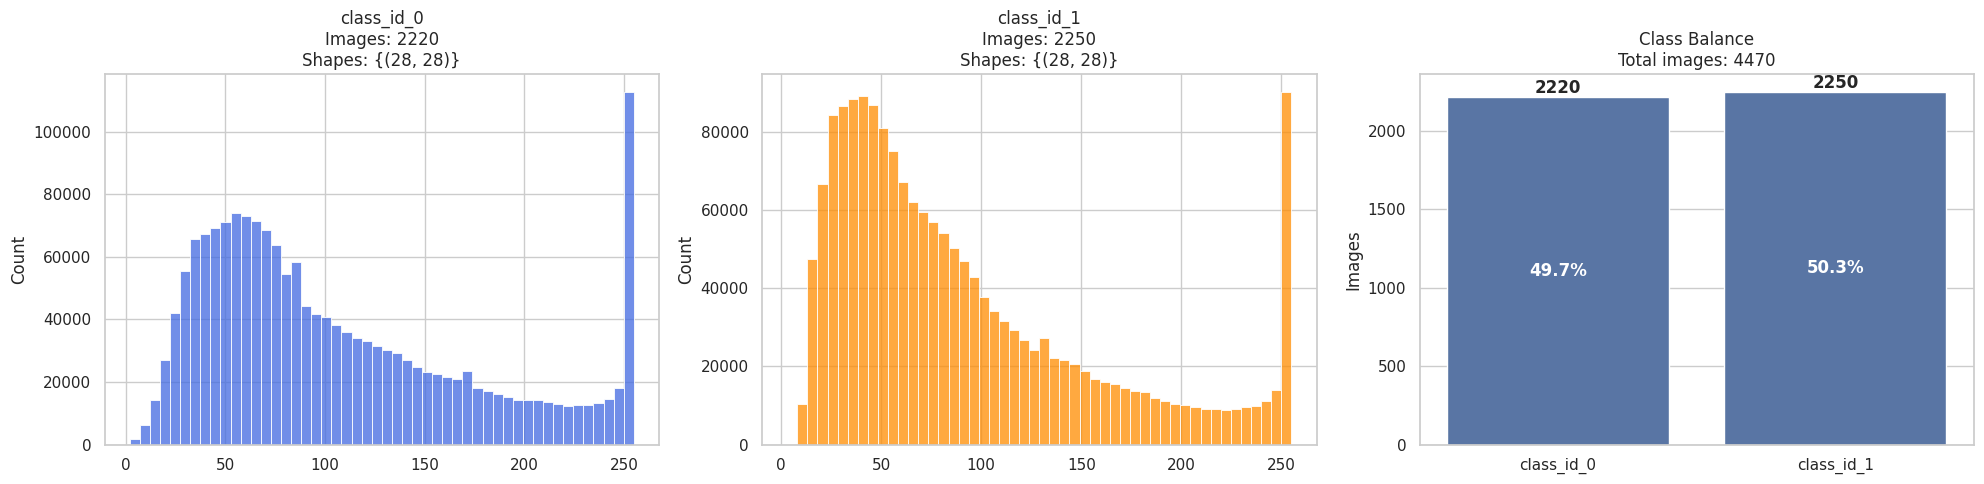

In [352]:
images, labels, class_names = load_and_analyze("data")

The analysis shows that both classes have similar pixel value distributions. 
A noticeable peak near pixel value 255 indicates a bright background, which helps distinguish the traffic sign from its surroundings. 

All images have identical dimensions (28×28), ensuring consistency across the dataset. 
Therefore, resizing is not required, and the images can be directly used for model training.

The dataset contains two classes with approximately equal numbers of samples.

- Speed limit 30: 2220 images (49.7%)
- Speed limit 50: 2250 images (50.3%)

The classes are well balanced, which is beneficial for training unbiased classification models.

In [260]:
def show_random_images(images, labels, class_names, n=16):

    plt.figure(figsize=(8, 8))

    for i in range(n):
        idx = np.random.randint(len(images))

        plt.subplot(4,4,i+1)

        if len(images[idx].shape) == 2:
            plt.imshow(images[idx], cmap='gray')
        else:
            plt.imshow(images[idx])

        plt.title(class_names[labels[idx]])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

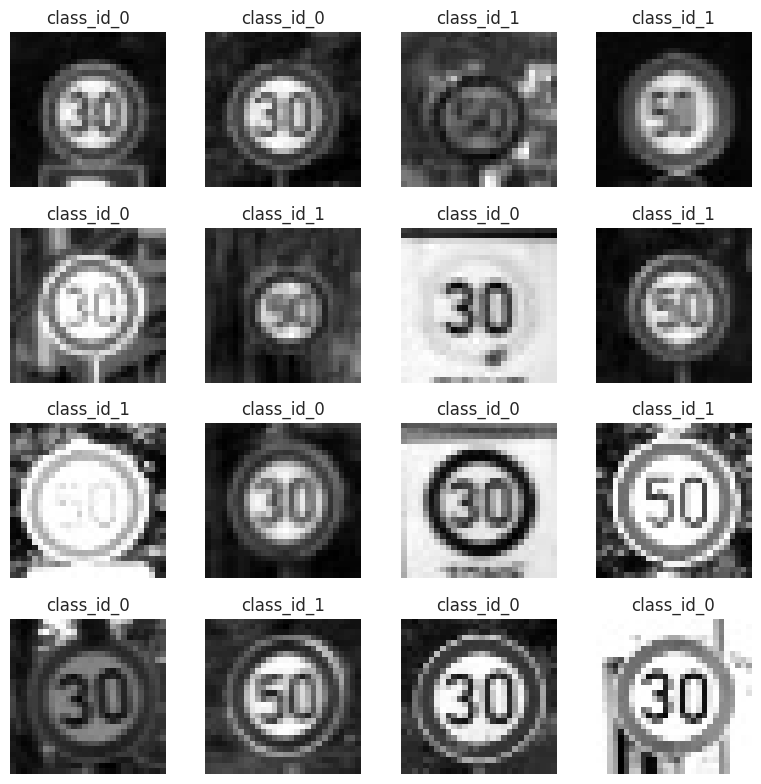

In [261]:
show_random_images(images, labels, class_names, n=16)

The images are low-resolution (28×28) and contain noticeable noise and variations in brightness and positioning.

Despite these limitations, the main patterns (digits 30 and 50) remain clearly distinguishable, making the classification task feasible.

## Data Preprocessing

Pixel values are normalized to [0, 1] by dividing by 255, which improves training stability and is standard for image data. Standardization was not applied, as normalization already provides stable training and no additional benefit is expected.

For MLP models, images are flattened into 784-dimensional vectors.  

In [262]:
def preprocess_images(images):

    # flatten images
    X = images.reshape(len(images), -1)

    # normalize pixel values
    X = X / 255.0

    print(X.shape)

    return X

In [263]:
X = preprocess_images(images)

(4470, 784)


## Train–Test Split

To evaluate the model properly, the dataset is divided into training and testing subsets.

A stratified split is used to preserve the class distribution in both subsets.  
This ensures that the proportion of the two traffic sign classes (Speed limit 30 and Speed limit 50) remains approximately the same in the training and test datasets.

Maintaining class balance during the split prevents bias in model evaluation and ensures that both classes are represented equally during training and testing.

In [264]:
from sklearn.model_selection import train_test_split

def split_dataset(X, labels, test_size=0.2):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        labels,
        test_size=test_size,
        stratify=labels,
        random_state=42
    )

    return X_train, X_test, y_train, y_test

In [265]:
X_train, X_test, y_train, y_test = split_dataset(X, labels)

In [266]:
def check_split_balance(y, name):

    unique, counts = np.unique(y, return_counts=True)

    total = len(y)

    print(name)

    for u, c in zip(unique, counts):

        print(f"class {u}: {c} ({c/total:.2%})")

    print()

In [267]:
check_split_balance(y_train, "Train set")
check_split_balance(y_test, "Test set")

Train set
class 0: 1776 (49.66%)
class 1: 1800 (50.34%)

Test set
class 0: 444 (49.66%)
class 1: 450 (50.34%)



A stratified train–test split was applied to preserve the original class distribution in both subsets.

The resulting training and test sets maintain an approximately equal proportion of the two classes, ensuring unbiased model training and evaluation.

# Baseline Model 1: single neuron

The first model uses a **single neuron** with a sigmoid activation function.

This model is equivalent to logistic regression and serves as a baseline model for the experiments.

Since the task is a binary classification problem, the model is trained using the binary cross-entropy loss function. The sigmoid activation function outputs a probability value between 0 and 1, representing the likelihood that an image belongs to one of the two classes.

The objective of training is to minimize the binary cross-entropy loss using gradient-based optimization.

In [268]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

def build_single_neuron_model(input_size):

    model = Sequential([
        Input(shape=(input_size,)),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [269]:
model_baseline = build_single_neuron_model(X_train.shape[1])

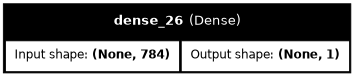

In [270]:
from tensorflow.keras.utils import plot_model

plot_model(
    model_baseline,
    show_shapes=True,
    show_layer_names=True,
    dpi=60
)

In [271]:
model_baseline.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 1)              │           785 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 785 (3.07 KB)

 Trainable params: 785 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

The model contains 785 trainable parameters
(784 weights and 1 bias term).

In [272]:
history_baseline = model_baseline.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5794 - loss: 0.6804 - val_accuracy: 0.6186 - val_loss: 0.6580
Epoch 2/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6628 - loss: 0.6332 - val_accuracy: 0.7013 - val_loss: 0.6100
Epoch 3/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7089 - loss: 0.5986 - val_accuracy: 0.7338 - val_loss: 0.5817
Epoch 4/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7369 - loss: 0.5752 - val_accuracy: 0.7315 - val_loss: 0.5698
Epoch 5/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7752 - loss: 0.5467 - val_accuracy: 0.7774 - val_loss: 0.5357
Epoch 6/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7836 - loss: 0.5279 - val_accuracy: 0.8188 - val_loss: 0.5202
Epoch 7/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8146 - loss: 0.5082 - val_accuracy: 0.8322 - val_loss: 0.5002
Epoch 8/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8263 - loss: 0.4935 - val_accuracy: 0.

In [273]:
def plot_training(history):

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title("Loss")
    plt.legend(["train","test"])

    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title("Accuracy")
    plt.legend(["train","test"])

    plt.show()

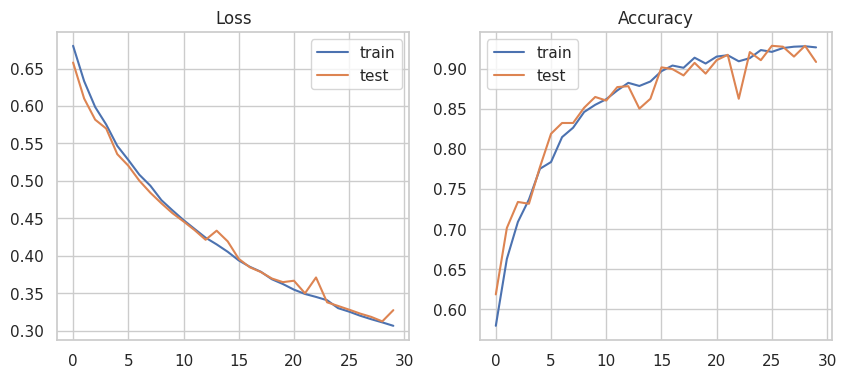

In [274]:
plot_training(history_baseline)

The following metrics are used to evaluate the models:

- Accuracy
- Precision
- Recall
- F1-score

In [275]:
def compute_metrics(model, X, y):

    preds = model.predict(X).flatten()
    preds = (preds > 0.5).astype(int)

    return {
        "Accuracy": accuracy_score(y, preds),
        "Precision": precision_score(y, preds),
        "Recall": recall_score(y, preds),
        "F1": f1_score(y, preds)
    }

In [276]:
def display_metrics(train_metrics, test_metrics):

    table = pd.DataFrame([
        {"Dataset": "Train", **train_metrics},
        {"Dataset": "Test", **test_metrics}
    ])

    return table

In [368]:
train_metrics_baseline = compute_metrics(model_baseline, X_train, y_train)
test_metrics_baseline  = compute_metrics(model_baseline, X_test, y_test)

display_metrics(train_metrics_baseline, test_metrics_baseline)

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


,Dataset,Accuracy,Precision,Recall,F1
0,Train,0.916667,0.866699,0.986111,0.922557
1,Test,0.908277,0.852490,0.988889,0.915638


### Error Analysis: Examples Where the _Baseline Model_ Makes Incorrect Predictions

In [435]:
def show_misclassified(model, X, y, n=10):
    label_map = {
        0: "30 km/h",
        1: "50 km/h"
    }

    preds = model.predict(X).flatten()
    preds_labels = (preds > 0.5).astype(int)

    wrong_idx = np.where(preds_labels != y)[0]

    plt.figure(figsize=(10, 4))
    
    for i, idx in enumerate(wrong_idx[:n]):
        plt.subplot(2, 5, i + 1)

        img = X[idx]

        # универсально:
        if img.ndim == 1:
            img = img.reshape(28, 28)
        else:
            img = img.squeeze()

        plt.imshow(img, cmap="gray")
        plt.title(
            f"True: {label_map[y[idx]]}\nPred: {label_map[preds_labels[idx]]}"
        )
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 947us/step


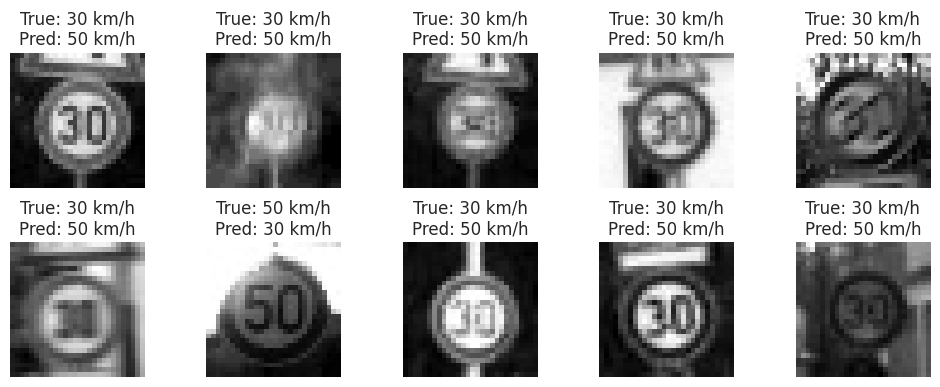

In [436]:
show_misclassified(model_baseline, X_test, y_test)

### Baseline Model 1 Results

The single-neuron model achieved strong performance despite its simplicity.

After 30 training epochs the model demonstrates good overall performance with balanced train and test metrics, indicating no overfitting.

The high recall suggests that most traffic signs are correctly detected, while the lower precision indicates the presence of some false positives.

Overall, the results confirm that the classes are largely linearly separable.

# Improved Model - Multilayer Perceptron (MLP)

To improve classification performance, hidden layers with ReLU activation are added.

This allows the network to learn more complex patterns in the data.

## Improved Model 2: MLP with One Hidden Layer
### 784 → 32 → 1

In [278]:
def build_mlp_32(input_size):

    model = Sequential([
        Input(shape=(input_size,)),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [279]:
model_mlp32 = build_mlp_32(X_train.shape[1])

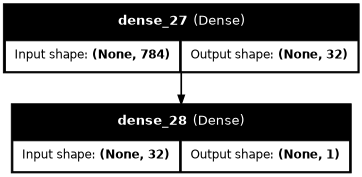

In [280]:
plot_model(
    model_mlp32,
    show_shapes=True,
    show_layer_names=True,
    dpi=60
)

In [281]:
model_mlp32.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,153 (98.25 KB)

 Trainable params: 25,153 (98.25 KB)

 Non-trainable params: 0 (0.00 B)

In [282]:
history_mlp32 = model_mlp32.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    #callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6600 - loss: 0.6277 - val_accuracy: 0.6812 - val_loss: 0.6049
Epoch 2/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7774 - loss: 0.5298 - val_accuracy: 0.8412 - val_loss: 0.4848
Epoch 3/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8336 - loss: 0.4629 - val_accuracy: 0.8546 - val_loss: 0.4331
Epoch 4/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8593 - loss: 0.4032 - val_accuracy: 0.8904 - val_loss: 0.3731
Epoch 5/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8839 - loss: 0.3571 - val_accuracy: 0.9150 - val_loss: 0.3350
Epoch 6/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8848 - loss: 0.3387 - val_accuracy: 0.9217 - val_loss: 0.3033
Epoch 7/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9262 - loss: 0.2860 - val_accuracy: 0.9139 - val_loss: 0.2832
Epoch 8/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9197 - loss: 0.2699 - val_accuracy: 0.

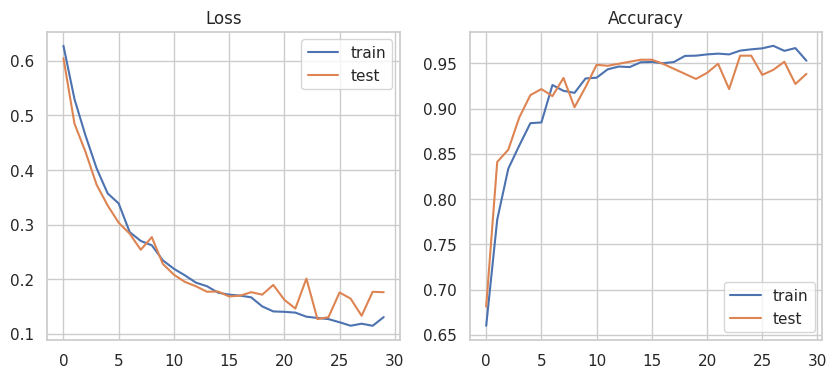

In [283]:
plot_training(history_mlp32)

In [369]:
train_metrics_mlp32 = compute_metrics(model_mlp32, X_train, y_train)
test_metrics_mlp32  = compute_metrics(model_mlp32, X_test, y_test)

display_metrics(train_metrics_mlp32, test_metrics_mlp32)

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


,Dataset,Accuracy,Precision,Recall,F1
0,Train,0.946029,0.906424,0.995556,0.948901
1,Test,0.938479,0.892644,0.997778,0.942288


### Error Analysis: Examples Where the _MLP (32 Hidden Units)_ Makes Incorrect Predictions

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


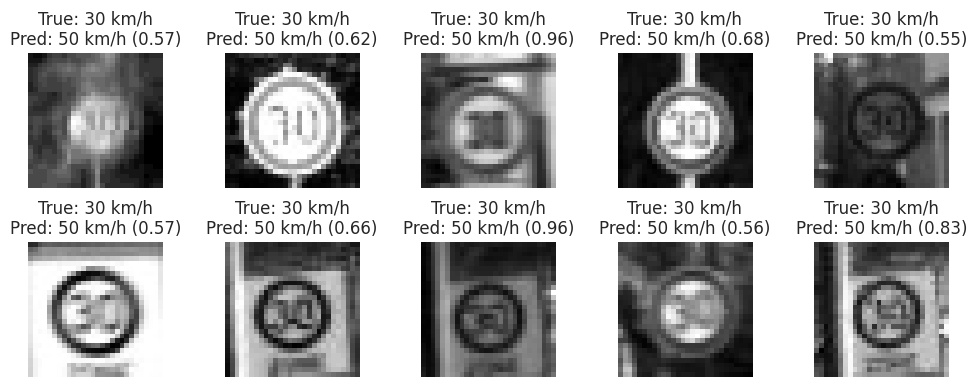

In [430]:
show_misclassified(model_mlp32, X_test, y_test)

### MLP (32 Hidden Units) Results

The MLP model with one hidden layer shows strong performance, achieving around 94–95% accuracy and F1-score on both training and test sets. The close alignment between train and test metrics indicates good generalization and no signs of overfitting.

Compared to the baseline model (≈91% accuracy), this architecture provides a noticeable improvement, confirming that adding a hidden layer helps capture more complex patterns.

The model achieves very high recall (≈99%), meaning that almost all traffic signs are correctly detected. Precision is slightly lower (≈89–90%), indicating the presence of some false positives.

Overall, even a small MLP significantly outperforms the linear baseline while remaining efficient.

## Improved Model 3: MLP with Two Hidden Layers

### 784 → 64 → 32 → 1

In [300]:
def build_mlp_64_32(input_size):

    model = Sequential([
        Input(shape=(input_size,)),
        Dense(64, activation="relu", name="hidden_layer_1"),
        Dense(32, activation="relu",  name="hidden_layer_2"),
        Dense(1, activation="sigmoid", name="output_layer")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [301]:
model_mlp64 = build_mlp_64_32(X_train.shape[1])

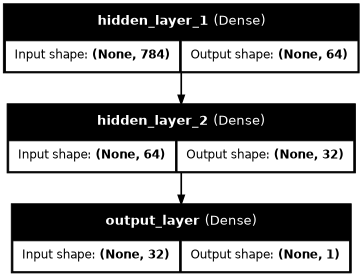

In [302]:
plot_model(
    model_mlp64,
    show_shapes=True,
    show_layer_names=True,
    dpi=60
)

In [303]:
model_mlp64.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,353 (204.50 KB)

 Trainable params: 52,353 (204.50 KB)

 Non-trainable params: 0 (0.00 B)

In [304]:
history_mlp64 = model_mlp64.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6530 - loss: 0.6202 - val_accuracy: 0.6935 - val_loss: 0.5765
Epoch 2/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7850 - loss: 0.4870 - val_accuracy: 0.7830 - val_loss: 0.4678
Epoch 3/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8395 - loss: 0.3916 - val_accuracy: 0.8244 - val_loss: 0.3981
Epoch 4/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8859 - loss: 0.3124 - val_accuracy: 0.8993 - val_loss: 0.2938
Epoch 5/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9027 - loss: 0.2722 - val_accuracy: 0.9351 - val_loss: 0.2355
Epoch 6/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9217 - loss: 0.2370 - val_accuracy: 0.7696 - val_loss: 0.4970
Epoch 7/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9183 - loss: 0.2239 - val_accuracy: 0.8993 - val_loss: 0.2535
Epoch 8/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9242 - loss: 0.2100 - val_accuracy: 0.

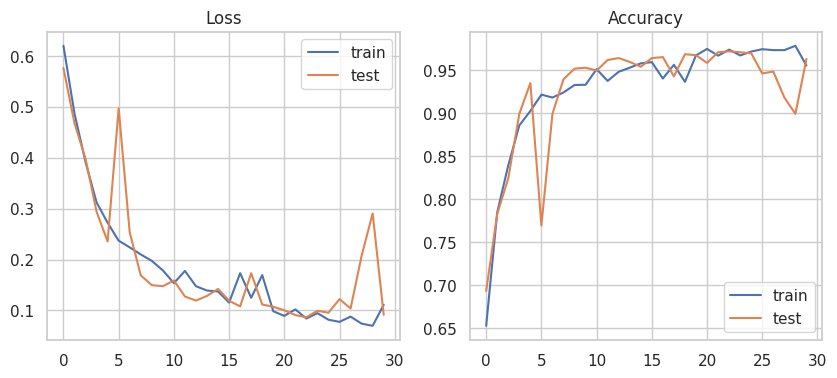

In [305]:
plot_training(history_mlp64)

In [370]:
train_metrics_mlp64 = compute_metrics(model_mlp64, X_train, y_train)
test_metrics_mlp64  = compute_metrics(model_mlp64, X_test, y_test)

display_metrics(train_metrics_mlp64, test_metrics_mlp64)

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,Dataset,Accuracy,Precision,Recall,F1
0,Train,0.974553,0.995937,0.953333,0.974170
1,Test,0.963087,0.979310,0.946667,0.962712


### Error Analysis: Examples Where the _MLP (64 → 32 Hidden Units)_ Makes Incorrect Predictions

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


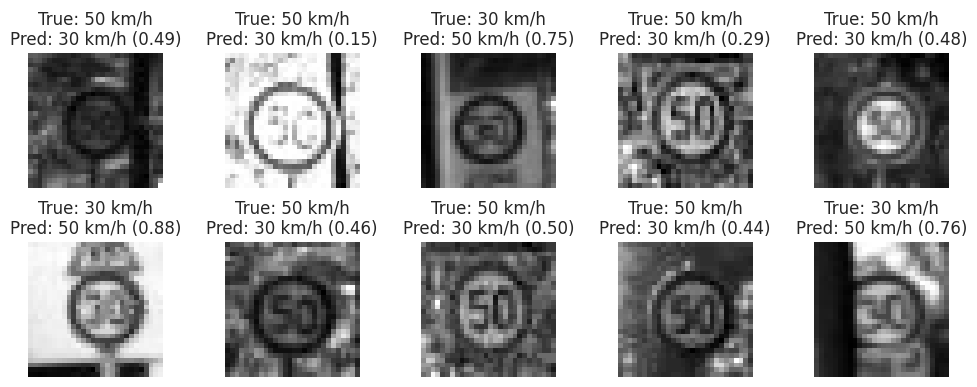

In [431]:
show_misclassified(model_mlp64, X_test, y_test)

### MLP (64 → 32 Hidden Units) Results

This MLP configuration achieves strong performance, with accuracy and F1-score around 96–97% on the training set and approximately 96% on the test set. The small gap between train and test metrics indicates good generalization with only minor signs of overfitting.

Compared to previous models, this architecture shows a clear improvement, suggesting that the increased capacity allows the network to better capture underlying patterns in the data.

In contrast to earlier models, precision is very high (≈98–99%), while recall is slightly lower (≈94–95%). This indicates that the model makes fewer false positives but may miss some true instances.

Overall, this model provides a better balance between precision and recall and represents one of the best-performing MLP configurations for this task.

## Improved Model 4: MLP with Two Hidden Layers + Dropout (Adam optimizer)
784 → 64 → Dropout → 32 → 1

In [323]:
def build_mlp_dropout(input_size, optimizer="adam"):

    model = Sequential([
        Input(shape=(input_size,)),
        Dense(64, activation="relu"),
        Dropout(0.1),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [324]:
model_mlp64_dropout = build_mlp_dropout(X_train.shape[1])

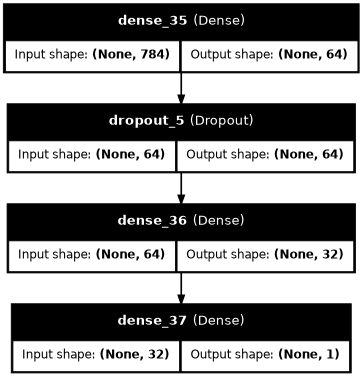

In [325]:
plot_model(
    model_mlp64_dropout,
    show_shapes=True,
    show_layer_names=True,
    dpi=60
)

In [326]:
model_mlp64_dropout.summary()

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_35 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,353 (204.50 KB)

 Trainable params: 52,353 (204.50 KB)

 Non-trainable params: 0 (0.00 B)

In [327]:
history_mlp64_dropout = model_mlp64_dropout.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5984 - loss: 0.6610 - val_accuracy: 0.6779 - val_loss: 0.6030
Epoch 2/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7441 - loss: 0.5457 - val_accuracy: 0.8221 - val_loss: 0.4527
Epoch 3/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7914 - loss: 0.4649 - val_accuracy: 0.8736 - val_loss: 0.3581
Epoch 4/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8714 - loss: 0.3459 - val_accuracy: 0.8960 - val_loss: 0.2794
Epoch 5/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8932 - loss: 0.2808 - val_accuracy: 0.8949 - val_loss: 0.2623
Epoch 6/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9083 - loss: 0.2601 - val_accuracy: 0.9452 - val_loss: 0.1882
Epoch 7/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9147 - loss: 0.2315 - val_accuracy: 0.9172 - val_loss: 0.2073
Epoch 8/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9301 - loss: 0.1940 - val_accuracy: 0.

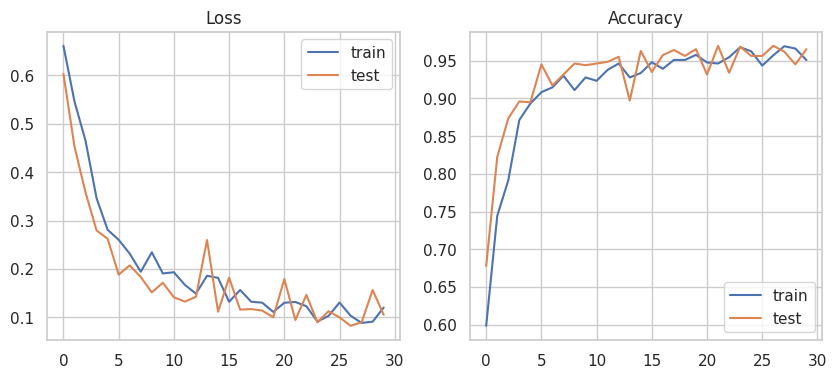

In [328]:
plot_training(history_mlp64_dropout)

In [371]:
train_metrics_mlp64_dropout_adam = compute_metrics(model_mlp64_dropout, X_train, y_train)
test_metrics_mlp64_dropout_adam  = compute_metrics(model_mlp64_dropout, X_test, y_test)

display_metrics(train_metrics_mlp64_dropout_adam, test_metrics_mlp64_dropout_adam)

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


,Dataset,Accuracy,Precision,Recall,F1
0,Train,0.984620,0.983380,0.986111,0.984743
1,Test,0.973154,0.963043,0.984444,0.973626


### Error Analysis: Examples Where the _MLP (64 → Dropout → 32 Hidden Units, Adam)_ Makes Incorrect Predictions

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


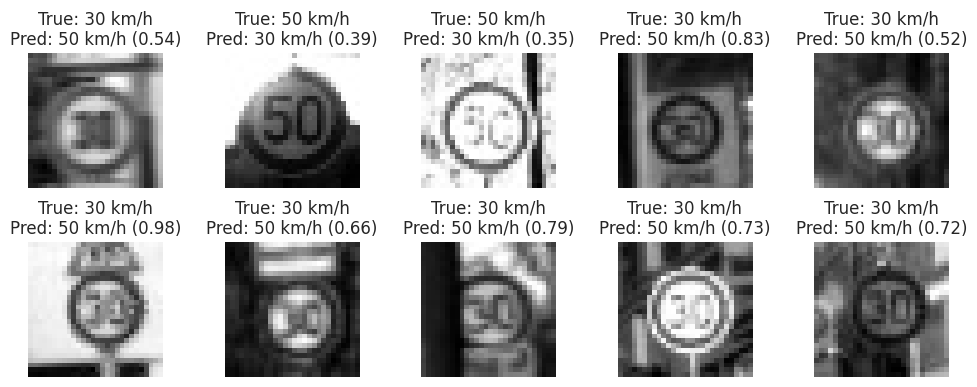

In [432]:
show_misclassified(model_mlp64_dropout, X_test, y_test)

### MLP (64 → Dropout → 32 Hidden Units, Adam) Results

This model achieves around 97–98% accuracy on the training set and approximately 96–97% on the test set, which is very similar to the same architecture without dropout.

While overall performance remains comparable, the balance between precision and recall slightly changes. With dropout, recall increases (≈95% → ≈98%), indicating fewer missed instances, while precision decreases (≈98% → ≈95%), suggesting more false positives.

This indicates that dropout does not provide a clear performance gain for this task, but rather shifts the model’s behavior. Given the simplicity of the dataset and the absence of overfitting in previous models, regularization does not bring significant benefits.

Overall, adding dropout does not improve the model, confirming that increased regularization is unnecessary in this case.

## Improved Model 5: MLP with Two Hidden Layers + Dropout (SGD optimizer)
784 → 64 → Dropout → 32 → 1

In [334]:
model_mlp64_dropout_sgd = build_mlp_dropout(X_train.shape[1], optimizer="sgd")

In [335]:
history_mlp64_dropout_sgd = model_mlp64_dropout_sgd.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5817 - loss: 0.6761 - val_accuracy: 0.6342 - val_loss: 0.6619
Epoch 2/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6415 - loss: 0.6501 - val_accuracy: 0.6678 - val_loss: 0.6375
Epoch 3/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6709 - loss: 0.6258 - val_accuracy: 0.6868 - val_loss: 0.6144
Epoch 4/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6907 - loss: 0.5987 - val_accuracy: 0.7069 - val_loss: 0.5922
Epoch 5/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7296 - loss: 0.5719 - val_accuracy: 0.7528 - val_loss: 0.5529
Epoch 6/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7534 - loss: 0.5374 - val_accuracy: 0.7819 - val_loss: 0.5194
Epoch 7/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7847 - loss: 0.5068 - val_accuracy: 0.8244 - val_loss: 0.4792
Epoch 8/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8056 - loss: 0.4679 - val_accuracy: 0.

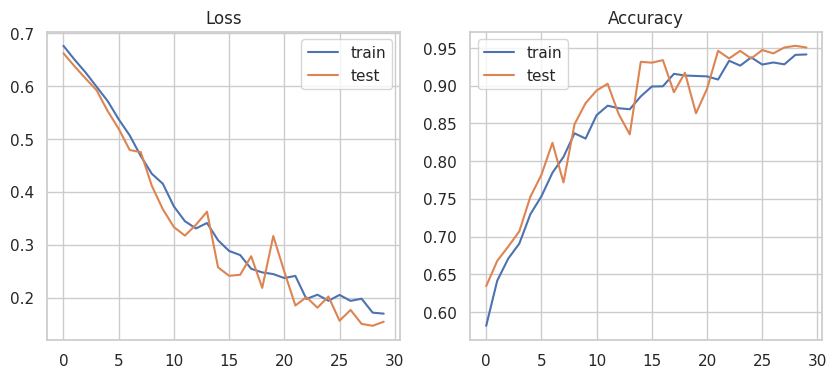

In [336]:
plot_training(history_mlp64_dropout_sgd)

In [372]:
train_metrics_mlp64_dropout_sgd = compute_metrics(model_mlp64_dropout_sgd, X_train, y_train)
test_metrics_mlp64_dropout_sgd  = compute_metrics(model_mlp64_dropout_sgd, X_test, y_test)

display_metrics(train_metrics_mlp64_dropout_sgd, test_metrics_mlp64_dropout_sgd)

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


,Dataset,Accuracy,Precision,Recall,F1
0,Train,0.960850,0.969989,0.951667,0.960740
1,Test,0.950783,0.961364,0.940000,0.950562


### Error Analysis: Examples Where the _MLP (64 → Dropout → 32 Hidden Units, SGD)_ Makes Incorrect Predictions

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


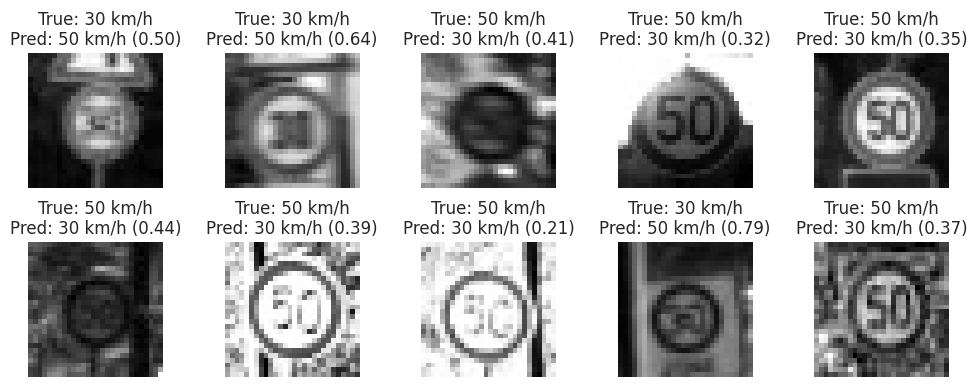

In [433]:
show_misclassified(model_mlp64_dropout_sgd, X_test, y_test)

### MLP (64 → Dropout → 32 Hidden Units, SGD) Results

Different optimizers lead to slightly different results. Adam achieves higher accuracy (≈96.5%) compared to SGD (≈95%), likely due to its adaptive learning rate and faster convergence.

However, the performance gap is relatively small, indicating that for this simple classification task, the choice of optimizer has a limited impact on the final performance.

## Early Stopping

Early stopping is typically used as a regularization technique to prevent overfitting. In this work, it is additionally employed to analyze convergence behavior, allowing us to identify whether the model reaches its optimal performance early and to assess the potential for reducing training time and computational cost.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta=0.001,
    restore_best_weights=True
)

In [339]:
history_mlp64_dropout_v2 = model_mlp64_dropout.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9648 - loss: 0.0946 - val_accuracy: 0.9732 - val_loss: 0.0790
Epoch 2/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9704 - loss: 0.0788 - val_accuracy: 0.9653 - val_loss: 0.0903
Epoch 3/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9709 - loss: 0.0750 - val_accuracy: 0.9631 - val_loss: 0.1139
Epoch 4/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9488 - loss: 0.1265 - val_accuracy: 0.9687 - val_loss: 0.0928
Epoch 5/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9678 - loss: 0.0841 - val_accuracy: 0.9597 - val_loss: 0.0990
Epoch 6/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9595 - loss: 0.1040 - val_accuracy: 0.9642 - val_loss: 0.0886


In [341]:
train_metrics = compute_metrics(model_mlp64_dropout, X_train, y_train)
test_metrics  = compute_metrics(model_mlp64_dropout, X_test, y_test)

display_metrics(train_metrics, test_metrics)

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,Dataset,Accuracy,Precision,Recall,F1
0,Train,0.984620,0.983380,0.986111,0.984743
1,Test,0.973154,0.963043,0.984444,0.973626


Overall, the task is relatively simple, as all models converge within a few epochs and achieve high performance. This suggests that the classes are easily separable and do not require complex architectures or extensive training. Moreover, most of the performance is achieved early in training, with additional epochs providing minimal improvement.

## Comparison of MLP Architectures

In [412]:
def build_results_table(models_metrics):
    rows = []
    index = []

    for model_name, train_metrics, test_metrics in models_metrics:
        row = []
        
        for metric in train_metrics.keys():
            row.append(train_metrics[metric])
            row.append(test_metrics[metric])
        
        rows.append(row)
        index.append(model_name)

    metrics = list(train_metrics.keys())
    columns = []

    for metric in metrics:
        columns.append((metric, "Train"))
        columns.append((metric, "Test"))

    multi_columns = pd.MultiIndex.from_tuples(columns)

    df = pd.DataFrame(rows, index=index, columns=multi_columns).round(4)

    return df

In [413]:
models_metrics = [
    ("Baseline", train_metrics_baseline, test_metrics_baseline),
    ("MLP 32", train_metrics_mlp32, test_metrics_mlp32),
    ("MLP 64-32", train_metrics_mlp64, test_metrics_mlp64),
    ("MLP 64-Dropout-32 (Adam)", train_metrics_mlp64_dropout_adam, test_metrics_mlp64_dropout_adam),
    ("MLP 64-Dropout-32 (SGD)", train_metrics_mlp64_dropout_sgd, test_metrics_mlp64_dropout_sgd),
]

results_df = build_results_table(models_metrics)

styled_df = results_df.style.format(precision=4).set_table_styles([
    {"selector": "thead th", "props": [("text-align", "center")]},
    {"selector": "tbody th", "props": [("text-align", "left"), ("padding-left", "8px")]},
    {"selector": "tbody td", "props": [("text-align", "center")]},
])

styled_df

### Analysis of MLP Architectures

Several multilayer perceptron (MLP) architectures were tested to improve the baseline model. 
Additional hidden layers and regularization techniques such as Dropout were introduced to increase model capacity and potentially improve generalization.

The results show that increasing the depth of the network leads to modest improvements over the baseline model. In particular, MLP architectures achieve slightly higher accuracy and F1-scores on the test set.

However, these gains remain relatively small, and deeper models do not provide a substantial advantage. In some cases, added complexity mainly changes the balance between precision and recall rather than improving overall performance.

This suggests that the classification problem is relatively simple and that the two classes are largely linearly separable. As a result, even a simple model already achieves strong performance, while more complex fully connected architectures offer only limited additional benefit.

To further improve performance, a model that better exploits the spatial structure of images can be used. For this purpose, a Convolutional Neural Network (CNN) will be implemented in the next section.

# Convolutional Neural Network (CNN)

Unlike fully connected neural networks, convolutional neural networks are specifically designed for image data. 
CNNs are able to capture spatial patterns such as edges, shapes, and local structures within images.

Instead of flattening the image into a vector of pixels, convolutional layers operate directly on the 2D structure of the image. 
This allows the model to learn more meaningful features and often leads to better performance in image classification tasks.

In [353]:
def preprocess_cnn(images):
    images = images.astype("float32")
    
    if images.max() > 1:
        images = images / 255.0
        
    if len(images.shape) == 3:
        images = images[..., None]
    
    print(f'images_cnn :{images.shape}')

    return images

In [359]:
from sklearn.model_selection import train_test_split

def split_data_cnn(X, y, test_size=0.2, random_state=42):

    X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
        X,
        y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    print(f'X_train_cnn.shape: {X_train_cnn.shape}')
    print(f'X_test_cnn.shape: {X_test_cnn.shape}')

    return X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn

In [355]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

def build_cnn_model(input_shape):

    model = Sequential([
        Input(shape=input_shape),

        Conv2D(32, (3,3), activation="relu"),
        MaxPooling2D((2,2)),

        Conv2D(64, (3,3), activation="relu"),
        MaxPooling2D((2,2)),

        Flatten(),

        Dense(64, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [360]:
images_cnn = preprocess_cnn(images)

images_cnn :(4470, 28, 28, 1)


In [361]:
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = split_data_cnn(images_cnn, labels)

X_train_cnn.shape: (3576, 28, 28, 1)
X_test_cnn.shape: (894, 28, 28, 1)


In [362]:
model_cnn = build_cnn_model((28, 28, 1))

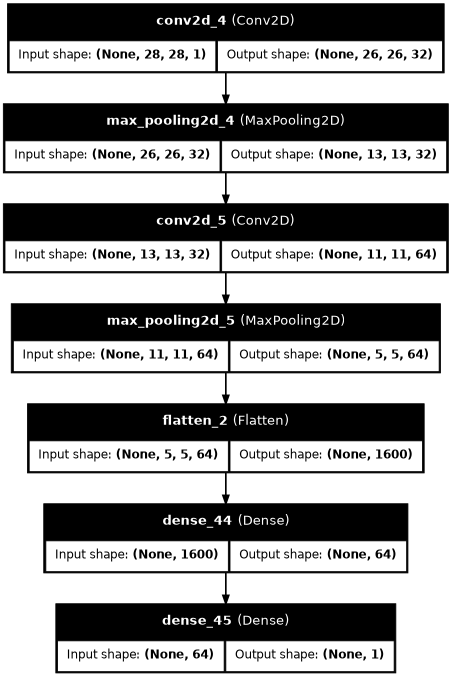

In [363]:
plot_model(
    model_cnn,
    show_shapes=True,
    show_layer_names=True,
    dpi=60
)

In [364]:
history_cnn = model_cnn.fit(
    X_train_cnn,
    y_train_cnn,
    epochs=30,
    batch_size=32,
    validation_data=(X_test_cnn, y_test_cnn)
)

Epoch 1/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6868 - loss: 0.5960 - val_accuracy: 0.8009 - val_loss: 0.4303
Epoch 2/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9309 - loss: 0.2308 - val_accuracy: 0.9799 - val_loss: 0.1188
Epoch 3/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9813 - loss: 0.0792 - val_accuracy: 0.9687 - val_loss: 0.0749
Epoch 4/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9863 - loss: 0.0513 - val_accuracy: 0.9832 - val_loss: 0.0538
Epoch 5/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9927 - loss: 0.0326 - val_accuracy: 0.9955 - val_loss: 0.0313
Epoch 6/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9944 - loss: 0.0246 - val_accuracy: 0.9933 - val_loss: 0.0267
Epoch 7/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9944 - loss: 0.0196 - val_accuracy: 0.9966 - val_loss: 0.0188
Epoch 8/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9972 - loss: 0.0135 - val_accuracy: 0

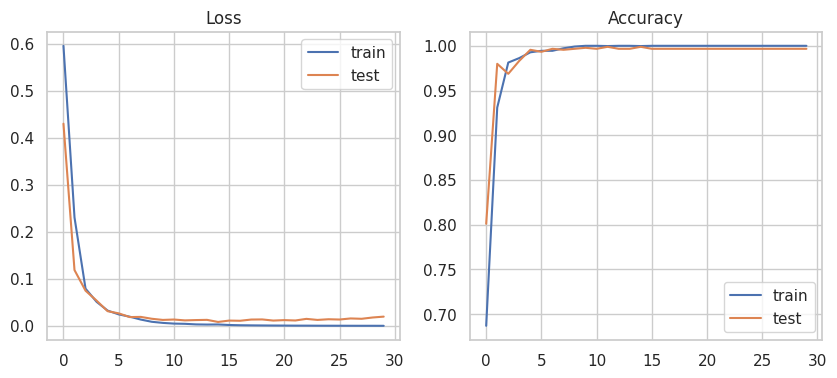

In [365]:
plot_training(history_cnn)

In [373]:
train_metrics_cnn = compute_metrics(model_cnn, X_train_cnn, y_train_cnn)
test_metrics_cnn  = compute_metrics(model_cnn, X_test_cnn, y_test_cnn)

display_metrics(train_metrics_cnn, test_metrics_cnn)

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


,Dataset,Accuracy,Precision,Recall,F1
0,Train,1.000000,1.000000,1.0,1.000000
1,Test,0.996644,0.993377,1.0,0.996678


### Error Analysis: Examples Where the _CNN Model_ Makes Incorrect Predictions

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


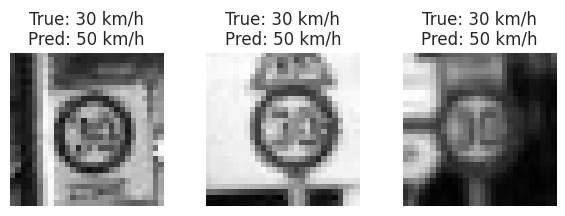

In [438]:
show_misclassified(model_cnn, X_test_cnn, y_test_cnn)

### CNN Model Results

The convolutional neural network achieved the best performance among all tested models.

The model reached perfect performance on the training set and very high accuracy on the test set (≈99.6–99.7%), indicating excellent generalization with only minimal overfitting.

Compared to the fully connected models, the CNN provides a clear improvement in performance. This can be explained by the ability of convolutional layers to capture spatial patterns such as edges and shapes in the images.

Unlike multilayer perceptrons, which operate on flattened pixel vectors, CNNs preserve the two-dimensional structure of the image and learn meaningful local features. This makes convolutional neural networks particularly effective for image classification tasks such as traffic sign recognition.

Overall, the CNN model achieves the best performance on this dataset, demonstrating that exploiting spatial information is crucial even for relatively simple image classification problems.

## Comparison of MLP and CNN Models

In [411]:
models_metrics = [
    ("Baseline", train_metrics_baseline, test_metrics_baseline),
    ("MLP 32", train_metrics_mlp32, test_metrics_mlp32),
    ("MLP 64-32", train_metrics_mlp64, test_metrics_mlp64),
    ("MLP 64-Dropout-32 (Adam)", train_metrics_mlp64_dropout_adam, test_metrics_mlp64_dropout_adam),
    ("MLP 64-Dropout-32 (SGD)", train_metrics_mlp64_dropout_sgd, test_metrics_mlp64_dropout_sgd),
    ("CNN", train_metrics_cnn, test_metrics_cnn),
]

results_df = build_results_table(models_metrics)

styled_df = results_df.style.format(precision=4).set_table_styles([
    {"selector": "thead th", "props": [("text-align", "center")]},
    {"selector": "tbody th", "props": [("text-align", "left"), ("padding-left", "8px")]},
    {"selector": "tbody td", "props": [("text-align", "center")]},
])

styled_df

## Conclusion

In this work, several models were evaluated for the task of binary traffic sign classification, ranging from a simple single-neuron baseline to more complex multilayer perceptrons and a convolutional neural network.

The baseline model already achieved solid performance, indicating that the two classes are largely linearly separable. Introducing hidden layers in MLP architectures led to modest improvements, but increasing model complexity beyond a certain point did not result in significant gains. Regularization techniques such as Dropout also did not provide clear benefits, as the models did not exhibit strong overfitting.

Additionally, experiments with different optimizers showed that while Adam slightly outperforms SGD, the impact of the optimizer is relatively small for this task.

A key observation is that all models converge within a few epochs, confirming that the classification problem is relatively simple and does not require extensive training.

The convolutional neural network achieved the best overall performance, reaching near-perfect accuracy on the test set. This demonstrates the importance of preserving spatial information, as CNNs are able to capture local patterns that fully connected models cannot.

In conclusion, while simple models already perform well on this task, CNNs provide the most effective solution. The results highlight that for image data, leveraging spatial structure is more important than increasing the depth of fully connected networks.